# Entrenamiento de una red neuronal con Enfriamiento simulado
Considere una red neuronal para la predicción de una serie de tiempo. La arquitectura de ésta es con $N_{input}=5$ (ajustable) entradas y una salida que, a su vez, se retroalimenta un periodo de tiempo; cuenta con 20 neuronas en la capa de entrada y 8 neuronas en la capa oculta, ambas de conexión densa.

Se desea encontrar los pesos $W_{input}$ para la capa de entrada, $W_1$ para la capa oculta y $W_{output}$ para la capa de salida, así como los valores de compensación o balance $b$, incluidos únicamente en la capa oculta.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Definición de la red neuronal
def red_neuronal(W, x, y_anterior):
    Winput = W[0]  # matriz de pesos de entrada.        Dimensión: 20 x (Ninput+1)
    W1 = W[1]  # matriz de pesos de la capa oculta. Dimensión:  8 x 20
    b = W[2]  # vector de balance.                 Dimensión:  8
    Woutput = W[3]  # matriz de pesos de salida.         Dimensión:  1 x 8
    x_1 = np.tanh(
        Winput @ np.concatenate([x, np.array([y_anterior])])
    )  # dimensiones: entrada = Ninput+1, salida = 20
    x_2 = np.tanh(W1 @ x_1 + b)  #              entrada = 20,       salida = 8
    y = np.tanh(Woutput @ x_2)  #                        8,                 1
    return y[0]

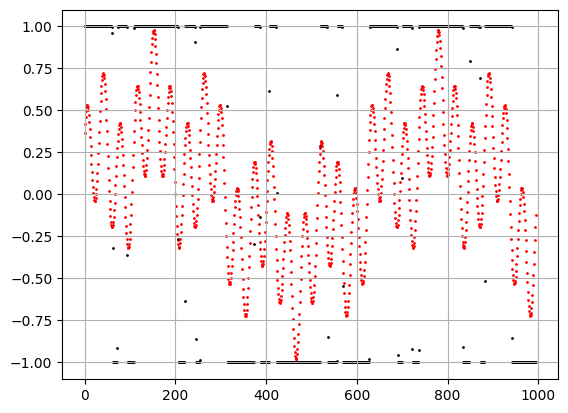

In [10]:
Ninput = (
    5  # Número de entradas (periodos de la serie necesarios para hacer la predicción)
)
# Pesos iniciales aleatorios
W0 = [
    np.random.rand(20, Ninput + 1),
    np.random.rand(8, 20),
    np.random.rand(8),
    np.random.rand(1, 8),
]
# Salida retroalimentada de la red
y0 = np.random.rand()

# Serie a predecir
t = np.linspace(0, 10, 1000)
serie = 0.35 * np.sin(t) + 0.25 * np.sin(t * 5) + 0.38 * np.sin(t * 17)

# Ejemplo de uso de la red con los parámetros aleatorios
prediccion = y0
for index in range(len(serie) - Ninput):
    x = serie[
        index : index + Ninput
    ]  # La entrada de la red se va desplazando en cada predicción
    y = serie[index + Ninput]  # Valor con el que se compara la predicción
    prediccion = red_neuronal(W0, x, prediccion)  # Esta es la predicción XD
    plt.scatter(index, prediccion, s=1, c="k")
    plt.scatter(index, y, s=1, c="r")
plt.grid()

---

In [11]:
def enfriamiento_simulado(E, vecino, T0, DeltaT, estado0):
    estado = estado0[:]
    T = T0
    acumulador = []
    while T > 1e-6:
        energia = E(estado)
        estado_new = vecino(estado)
        energia_new = E(estado_new)
        acumulador.append(energia)
        if energia_new < energia:
            estado = estado_new[:]
        else:
            probabilidad = np.exp(-(energia_new - energia) / T)
            if probabilidad > np.random.rand():
                estado = estado_new[:]
        T *= DeltaT  # Decremento geométrico. T -= DeltaT # Decremento lineal
    return estado, acumulador

In [12]:
def mse(estado):
    error = []
    prediccion = y0
    for index in range(len(serie) - Ninput):
        x = serie[
            index : index + Ninput
        ]  # La entrada de la red se va desplazando en cada predicción
        y = serie[index + Ninput]  # Valor con el que se compara la predicción
        prediccion = red_neuronal(estado, x, prediccion)  # Esta es la predicción XD
        error.append((prediccion - y) ** 2)
    return np.array(error).mean()


def generar_vecino(estado):
    estado_new = estado[:]
    for index in range(len(estado)):
        estado_new[index] = estado_new[index] + estado_new[index] * np.random.uniform(
            -0.01, 0.01, estado_new[index].shape
        )
    return estado_new

In [33]:
mejorW, acumulador = enfriamiento_simulado(mse, generar_vecino, 1000, 0.999, W0)
# mejorW,acumulador=enfriamiento_simulado(mse,generar_vecino,100,0.99,mejorW)

0.044898205053288544


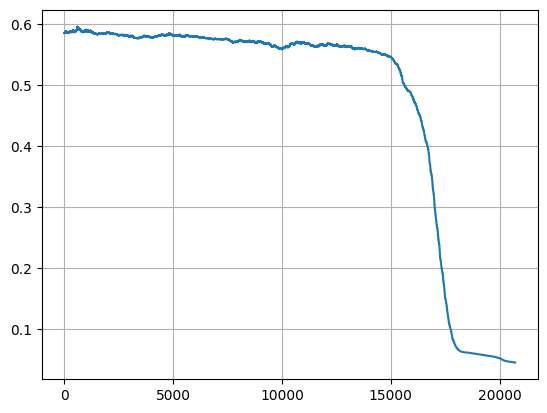

In [34]:
plt.plot(acumulador)
plt.grid()
print(acumulador[-1])

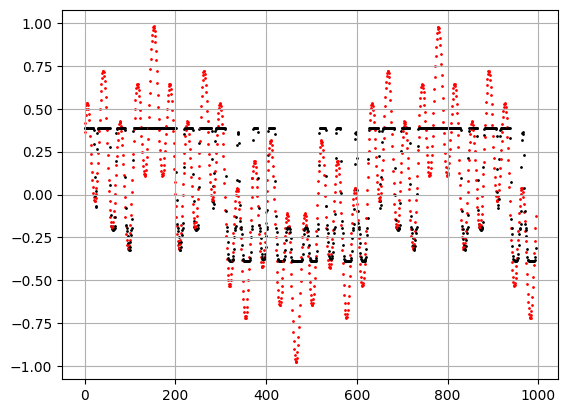

In [35]:
prediccion = y0
for index in range(len(serie) - Ninput):
    x = serie[
        index : index + Ninput
    ]  # La entrada de la red se va desplazando en cada predicción
    y = serie[index + Ninput]  # Valor con el que se compara la predicción
    prediccion = red_neuronal(mejorW, x, prediccion)  # Esta es la predicción XD
    plt.scatter(index, prediccion, s=1, c="k")
    plt.scatter(index, y, s=1, c="r")
plt.grid()